In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

In [19]:
data=pd.read_csv('Transactn1.csv')
data1=pd.read_csv('DTI.csv')
data2=pd.read_csv('DTi_Branch.csv')
data3=pd.read_csv('Loan_risk.csv')

In [121]:
data2.head()

,Customer_ID,Income,Monthly_income,Total_loan_amount,Total_loan_payment,DTI,LTI,Branch
0,CUST1001,4467228,372269.00,1488621,13098.17,3.52,0.33,CHENNAI
1,CUST1003,3508627,292385.58,7285879,80427.07,27.51,2.08,CALICUT
2,CUST1003,3508627,292385.58,7285879,80427.07,27.51,2.08,TRIVANDRUM
3,CUST1004,3740188,311682.33,9482189,305919.05,98.15,2.54,TRIVANDRUM
4,CUST1007,2911500,242625.00,3623087,42786.32,17.63,1.24,CHENNAI


Branch
CALICUT       3772
CHENNAI       3716
KOCHI         3760
TRIVANDRUM    3752
Name: Transaction_ID, dtype: int64


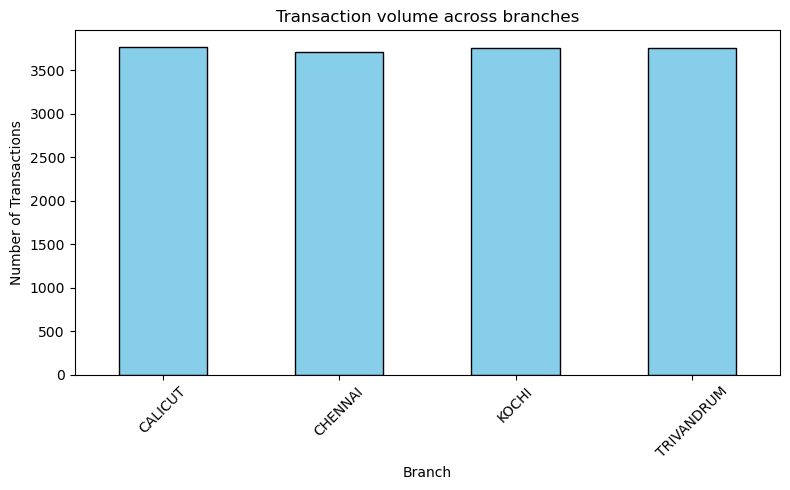

In [5]:
# compare transaction volume across branches

txn_volume=data.groupby('Branch')['Transaction_ID'].count()


print(txn_volume)

#visualize

txn_volume.plot(kind='bar',figsize=(8,5),color='skyblue',edgecolor='black')
plt.title('Transaction volume across branches')
plt.xlabel('Branch')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Branch
CALICUT       1.578845e+11
CHENNAI       1.802705e+11
KOCHI         1.685908e+11
TRIVANDRUM    1.673623e+11
Name: Amount_in_INR, dtype: float64


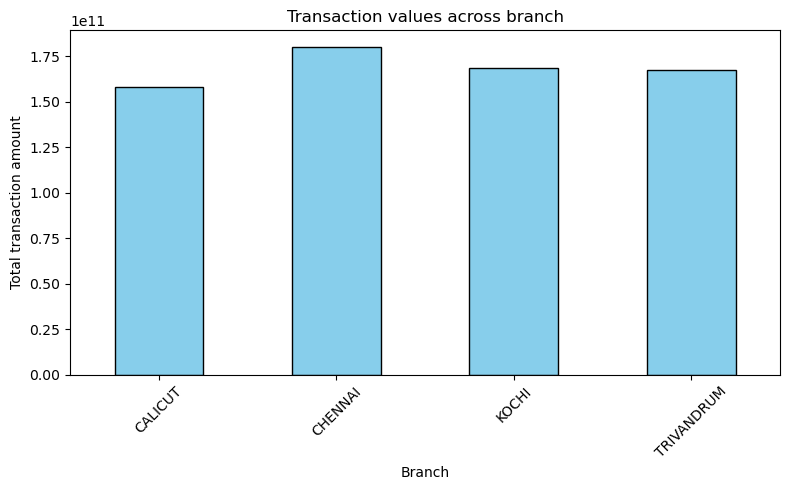

In [7]:
#compare txn value across branch

txn_value=data.groupby('Branch')['Amount_in_INR'].sum()


print(txn_value)

#visualize

txn_value.plot(kind='bar',figsize=(8,5),color='skyblue',edgecolor='black')
plt.title('Transaction values across branch')
plt.xlabel('Branch')
plt.ylabel('Total transaction amount')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

            Transaction_ID  Amount_in_INR
Branch                                   
CALICUT               3772   1.578845e+11
CHENNAI               3716   1.802705e+11
KOCHI                 3760   1.685908e+11
TRIVANDRUM            3752   1.673623e+11


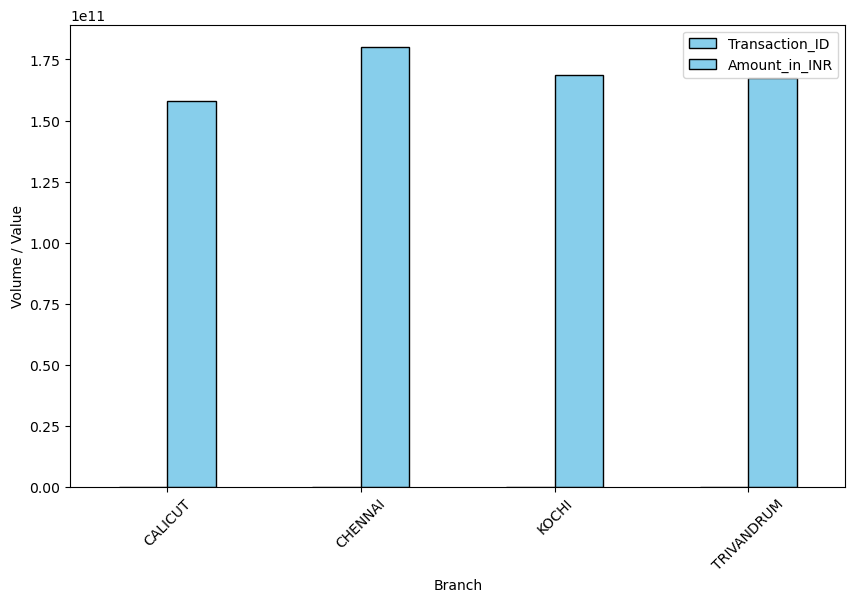

In [9]:
branch=pd.concat([txn_volume,txn_value],axis=1)
print(branch)


branch.plot(kind='bar',figsize=(10,6),color='skyblue',edgecolor='black')
plt.xlabel('Branch')
plt.ylabel('Volume / Value')
plt.xticks(rotation=45)
plt.show()


In [11]:
#Consistency in credit quality across locations

#count distinct branches per customer

branch_count=data.groupby('Customer_ID')['Branch'].nunique().reset_index(name='Branch_count')
b_data=pd.DataFrame(branch_count)
#print(b_data)

#Tag customers as single or multi branch

#b_data['Branch_Tag']=b_data['Branch_Tag'].apply(lambda b_data['Branch_count']: 'Multi_branch' if b_data['Branch_count'] > 1 else 'Single_branch')

#assigning branch as most transaction happened

branch_map = data.groupby(['Customer_ID','Branch']).size().reset_index(name='txn_count')
#print(branch_map)

primary_branch = branch_map.loc[branch_map.groupby('Customer_ID')['txn_count'].idxmax()]
p_data=pd.DataFrame(primary_branch)
print(p_data)

p_data.to_csv(r'E:\Data Analysis\Project\Loan\Primary_branch.csv',index=False)
#merging with dti table

dti_with_branch=data1.merge(primary_branch[['Customer_ID','Branch']],on='Customer_ID',how='left')

dti_with_branch.info()

      Customer_ID      Branch  txn_count
0        CUST1000  TRIVANDRUM          2
1        CUST1001     CHENNAI          1
2        CUST1003     CALICUT          1
4        CUST1004  TRIVANDRUM          1
5        CUST1005     CALICUT          1
...           ...         ...        ...
12233    CUST9993  TRIVANDRUM          1
12234    CUST9995     CALICUT          1
12236    CUST9996     CALICUT          2
12237    CUST9997     CHENNAI          1
12238    CUST9999     CHENNAI          1

[7307 rows x 3 columns]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3043 entries, 0 to 3042
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Customer_ID         3043 non-null   object 
 1   Income              3043 non-null   int64  
 2   Monthly_income      3043 non-null   float64
 3   Total_loan_amount   3043 non-null   int64  
 4   Total_loan_payment  3043 non-null   float64
 5   DTI                 3043 non-

In [93]:
#cross-checking
#customers with no transaction record

missing_ids = dti_with_branch[dti_with_branch['Branch'].isna()]['Customer_ID']
missing_ids.head()

#customers with transaction record

txn_ids=set(data['Customer_ID'])
no_txn_customer= set(missing_ids) - txn_ids

#print(len(txn_ids))
#print(len(no_txn_customer))

In [15]:
dti_branch_known=dti_with_branch.loc[dti_with_branch['Branch'].isin(['CALICUT','CHENNAI','KOCHI','TRIVANDRUM'])]

#dti_branch_known.info()

#Aggregating credit quality

branch_quality = dti_branch_known.groupby('Branch').agg(
    avg_dti=('DTI','mean'),
    avg_lti=('LTI','mean'),
    med_dti=('DTI','median'),
    p75_dti=('DTI',lambda x: x.quantile(0.75)),
    p90_dti=('DTI',lambda x: x.quantile(0.90)),
    p95_dti=('DTI',lambda x: x.quantile(0.95)),
    pct_dti_50=('DTI',lambda x:(x >50).mean()*100),
    pct_dti_100=('DTI',lambda x:(x >100).mean()*100),
    avg_income=('Monthly_income','mean'),
    avg_loan_amount=('Total_loan_amount','mean'),
    customer_count=('Customer_ID','count')
).reset_index()

#print(branch_quality)

#creating a Data frame

branch_df=pd.DataFrame(branch_quality)
print(branch_df)

       Branch     avg_dti   avg_lti  med_dti   p75_dti  p90_dti  p95_dti  \
0     CALICUT  148.163363  4.044857   78.285  170.0575  332.107  492.765   
1     CHENNAI  190.319899  4.764691   78.550  197.0050  377.110  612.044   
2       KOCHI  172.921954  4.798087   89.390  186.0500  357.730  553.210   
3  TRIVANDRUM  159.766740  4.247737   74.020  162.4350  351.500  627.970   

   pct_dti_50  pct_dti_100     avg_income  avg_loan_amount  customer_count  
0   63.516484    41.538462  256342.368868     8.411723e+06             910  
1   62.877698    44.028777  255488.706086     8.568709e+06             695  
2   66.320166    44.906445  251569.770312     8.408383e+06             481  
3   60.097324    39.659367  254838.344209     8.070724e+06             411  


In [17]:
branch_df.head()

,Branch,avg_dti,avg_lti,med_dti,p75_dti,p90_dti,p95_dti,pct_dti_50,pct_dti_100,avg_income,avg_loan_amount,customer_count
0,CALICUT,148.163363,4.044857,78.285,170.0575,332.107,492.765,63.516484,41.538462,256342.368868,8.411723e+06,910
1,CHENNAI,190.319899,4.764691,78.550,197.0050,377.110,612.044,62.877698,44.028777,255488.706086,8.568709e+06,695
2,KOCHI,172.921954,4.798087,89.390,186.0500,357.730,553.210,66.320166,44.906445,251569.770312,8.408383e+06,481
3,TRIVANDRUM,159.766740,4.247737,74.020,162.4350,351.500,627.970,60.097324,39.659367,254838.344209,8.070724e+06,411


In [129]:
#dti bucket

bins=[-1,30,50,100,float('inf')]
labels=['<30','30-50','50-100','>100']
dti_with_branch['dti_bucket']=pd.cut(dti_with_branch['DTI'],bins=bins,labels=labels)

bucket_count=dti_with_branch.groupby(['Branch','dti_bucket']).size().unstack(fill_value=0)
bucket_pct=bucket_count.div(bucket_count.sum(axis=1),axis=0)*100

print(bucket_count)
print(bucket_pct.round(2))

dti_bucket  <30  30-50  50-100  >100
Branch                              
CALICUT     229    103     200   378
CHENNAI     153    105     131   306
KOCHI       105     57     103   216
TRIVANDRUM   99     65      84   163
dti_bucket    <30  30-50  50-100   >100
Branch                                 
CALICUT     25.16  11.32   21.98  41.54
CHENNAI     22.01  15.11   18.85  44.03
KOCHI       21.83  11.85   21.41  44.91
TRIVANDRUM  24.09  15.82   20.44  39.66


C:\Users\Admin\AppData\Local\Temp\ipykernel_2672\3941407877.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bucket_count=dti_with_branch.groupby(['Branch','dti_bucket']).size().unstack(fill_value=0)


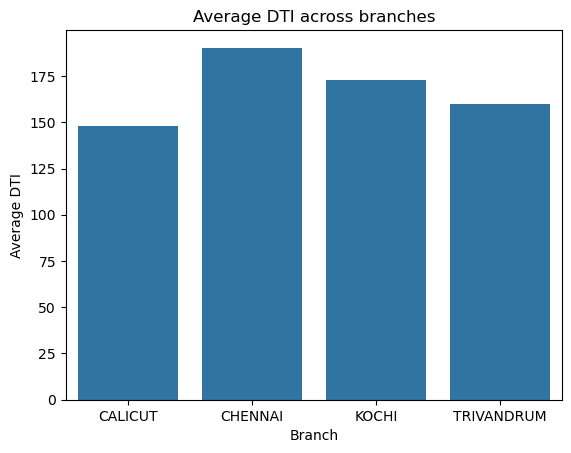

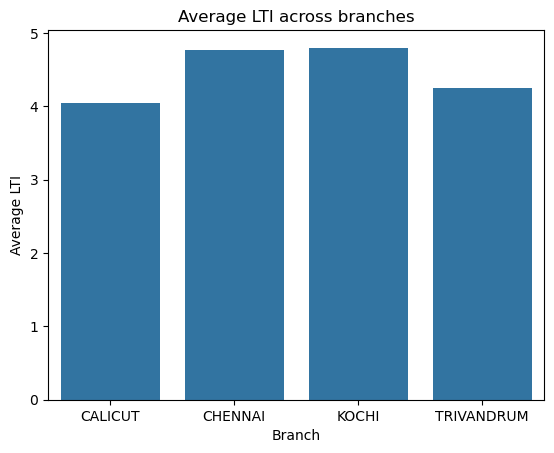

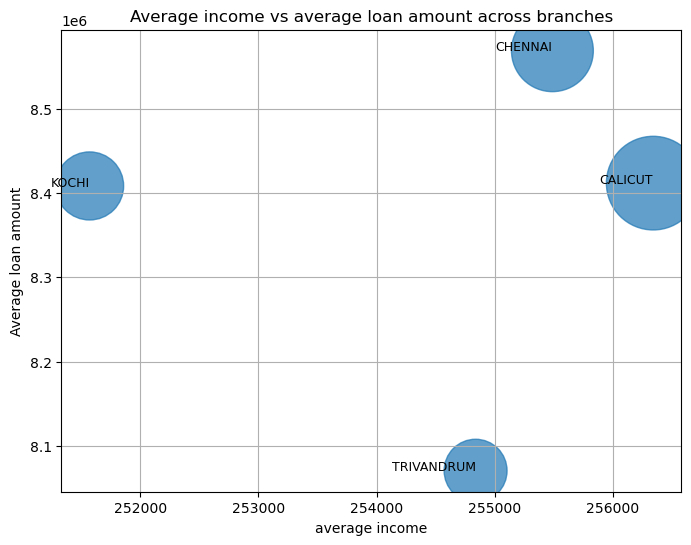

In [115]:
#visualize

sns.barplot(x=branch_quality['Branch'],y=branch_quality['avg_dti'])
plt.xlabel('Branch')
plt.ylabel('Average DTI')
plt.title('Average DTI across branches')
plt.show()

#avg_lti vs branch
sns.barplot(x=branch_quality['Branch'],y=branch_quality['avg_lti'])
plt.xlabel('Branch')
plt.ylabel('Average LTI')
plt.title('Average LTI across branches')
plt.show()

#avg income vs avg total loan amount

plt.figure(figsize=(8,6))
plt.scatter(x=branch_quality['avg_income'],y=branch_quality['avg_loan_amount'],s=branch_quality['customer_count']*5,alpha=0.7)

#annote branch names

for i, row in branch_quality.iterrows():
    plt.text(row['avg_income'],row['avg_loan_amount'],row['Branch'],fontsize=9,ha='right')

plt.xlabel('average income')
plt.ylabel('Average loan amount')
plt.title('Average income vs average loan amount across branches')
plt.grid(True)
plt.show()

In [59]:
#activity based aggregation

customer_activity=data.groupby('Customer_ID')['Branch'].unique().reset_index()

customer_activity=customer_activity.explode('Branch')
#print(customer_activity)

activity_with_metrics=customer_activity.merge(data1[['Customer_ID','Income','Monthly_income','DTI','LTI','Total_loan_amount']],on='Customer_ID',how='left')
activity_B_known=activity_with_metrics.loc[activity_with_metrics['Branch'].isin(['CALICUT','CHENNAI','KOCHI','TRIVANDRUM'])]
#activity_B_known.info()

#credit quality aggregation

branch_stats=activity_B_known.groupby(['Customer_ID','Branch']).agg(
     avg_dti=('DTI','mean'),
     avg_lti=('LTI','mean'),
     med_dti=('DTI','median'),
     p75_dti=('DTI',lambda x: x.quantile(0.75)),
     p90_dti=('DTI',lambda x: x.quantile(0.90)),
     p95_dti=('DTI',lambda x: x.quantile(0.95)),
     pct_dti_50=('DTI',lambda x:(x>50).mean()*100),
     pct_dti_100=('DTI',lambda x:(x>100).mean()*100),
     avg_income=('Income','mean'),
     avg_total_loan=('Total_loan_amount','mean'),
     customer_count=('Customer_ID','count')
)

print(branch_stats)
#dti bucket

bins=[-1,30,50,100,float('inf')]
labels=['<30','30-50','50-100','>100']
activity_B_known['dti_bucket']=pd.cut(activity_B_known['DTI'],bins=bins,labels=labels)

bucket_counts=activity_B_known.groupby(['Branch','dti_bucket']).size().unstack(fill_value=0)
Bucket_pct=bucket_counts.div(bucket_counts.sum(axis=1),axis=0)*100

#print(bucket_counts)
#print(Bucket_pct.round(2))

                        avg_dti  avg_lti  med_dti  p75_dti  p90_dti  p95_dti  \
Customer_ID Branch                                                             
CUST1000    TRIVANDRUM      NaN      NaN      NaN      NaN      NaN      NaN   
CUST1001    CHENNAI        3.52     0.33     3.52     3.52     3.52     3.52   
CUST1003    CALICUT       27.51     2.08    27.51    27.51    27.51    27.51   
            TRIVANDRUM    27.51     2.08    27.51    27.51    27.51    27.51   
CUST1004    TRIVANDRUM    98.15     2.54    98.15    98.15    98.15    98.15   
...                         ...      ...      ...      ...      ...      ...   
CUST9995    CALICUT         NaN      NaN      NaN      NaN      NaN      NaN   
            KOCHI           NaN      NaN      NaN      NaN      NaN      NaN   
CUST9996    CALICUT         NaN      NaN      NaN      NaN      NaN      NaN   
CUST9997    CHENNAI         NaN      NaN      NaN      NaN      NaN      NaN   
CUST9999    CHENNAI         NaN      NaN

C:\Users\Admin\AppData\Local\Temp\ipykernel_18532\1848840576.py:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bucket_counts=activity_B_known.groupby(['Branch','dti_bucket']).size().unstack(fill_value=0)


In [21]:
#operation inefficiency

#age of pending cases

data['Transaction_Date']=pd.to_datetime(data['Transaction_Date'])
today=pd.Timestamp.now()

data['Pending_days']=(today - data['Transaction_Date']).dt.days.where(data['Status']=='PENDING')
avg_pending=data.groupby('Branch')['Pending_days'].mean()

#error rate

error_rate=data.groupby('Branch')['Status'].apply(lambda x: (x=='FAILED').mean()*100)

#unknown_rate

unk_rate=data.groupby('Branch')['Status'].apply(lambda x: (x=='UNKNOWN').mean()*100)

#throughput

data['Month']=data['Transaction_Date'].dt.to_period('M')
monthly_count=data.groupby(['Branch','Month'])['Transaction_ID'].count()
throughput=monthly_count.groupby('Branch').mean()

#operational metrics
ops_metrics=pd.DataFrame({
    "Branch":error_rate.index,
    "Error_rate":error_rate.values,
    "Unknwon_rate":unk_rate.values,
    "Avg_pending_days":avg_pending.values,
    "Avg_throughput":throughput.values
})

In [45]:
print(monthly_count)

Branch      Month  
CALICUT     2018-01    41
            2018-02    45
            2018-03    45
            2018-04    50
            2018-05    43
                       ..
TRIVANDRUM  2024-07    38
            2024-08    57
            2024-09    46
            2024-10    41
            2024-11     5
Name: Transaction_ID, Length: 332, dtype: int64


In [53]:
data.head()

,Transaction_ID,Customer_ID,Branch,Transaction_Date,Transaction_Type,Amount,Currency,Status,Amount_in_INR,Pending_days,Month
0,TXN833420,CUST2665,TRIVANDRUM,2023-01-07,DEPOSIT,389650.0,INR,UNKNOWN,389650.0,NaN,2023-01
1,TXN659381,CUST9640,CHENNAI,2019-01-12,WITHDRAWAL,3793001.0,USD,PENDING,314819083.0,2658.0,2019-01
2,TXN880101,CUST3248,CALICUT,2018-01-16,WITHDRAWAL,2160839.0,INR,UNKNOWN,2160839.0,NaN,2018-01
3,TXN823601,CUST2120,KOCHI,2020-12-18,WITHDRAWAL,1180522.0,USD,SUCCESS,97983326.0,NaN,2020-12
4,TXN318577,CUST2707,TRIVANDRUM,2021-09-20,WITHDRAWAL,4326846.0,INR,PENDING,4326846.0,1676.0,2021-09


In [23]:
Branch_ops_df=branch_df.merge(ops_metrics,on='Branch')

In [25]:
Branch_ops_df.head()

,Branch,avg_dti,avg_lti,med_dti,p75_dti,p90_dti,p95_dti,pct_dti_50,pct_dti_100,avg_income,avg_loan_amount,customer_count,Error_rate,Unknwon_rate,Avg_pending_days,Avg_throughput
0,CALICUT,148.163363,4.044857,78.285,170.0575,332.107,492.765,63.516484,41.538462,256342.368868,8.411723e+06,910,20.599152,20.996819,1819.818674,45.445783
1,CHENNAI,190.319899,4.764691,78.550,197.0050,377.110,612.044,62.877698,44.028777,255488.706086,8.568709e+06,695,19.429494,21.151776,1766.822626,44.771084
2,KOCHI,172.921954,4.798087,89.390,186.0500,357.730,553.210,66.320166,44.906445,251569.770312,8.408383e+06,481,20.132979,20.425532,1807.804521,45.301205
3,TRIVANDRUM,159.766740,4.247737,74.020,162.4350,351.500,627.970,60.097324,39.659367,254838.344209,8.070724e+06,411,19.029851,20.335821,1766.177806,45.204819


In [33]:
#fitering
branch_analysis=Branch_ops_df[['Branch','avg_dti','avg_income','avg_loan_amount','Error_rate','Unknwon_rate','Avg_pending_days','Avg_throughput']]
#checking correlation

corr=branch_analysis.corr(numeric_only=True)
print(corr)

                   avg_dti  avg_income  avg_loan_amount  Error_rate  \
avg_dti           1.000000   -0.279168         0.548747   -0.423164   
avg_income       -0.279168    1.000000         0.046303   -0.029517   
avg_loan_amount   0.548747    0.046303         1.000000    0.458890   
Error_rate       -0.423164   -0.029517         0.458890    1.000000   
Unknwon_rate      0.265282    0.654651         0.784839    0.302110   
Avg_pending_days -0.547202   -0.162614         0.254904    0.969483   
Avg_throughput   -0.887649   -0.143858        -0.398696    0.629254   

                  Unknwon_rate  Avg_pending_days  Avg_throughput  
avg_dti               0.265282         -0.547202       -0.887649  
avg_income            0.654651         -0.162614       -0.143858  
avg_loan_amount       0.784839          0.254904       -0.398696  
Error_rate            0.302110          0.969483        0.629254  
Unknwon_rate          1.000000          0.063475       -0.417843  
Avg_pending_days      0.06347

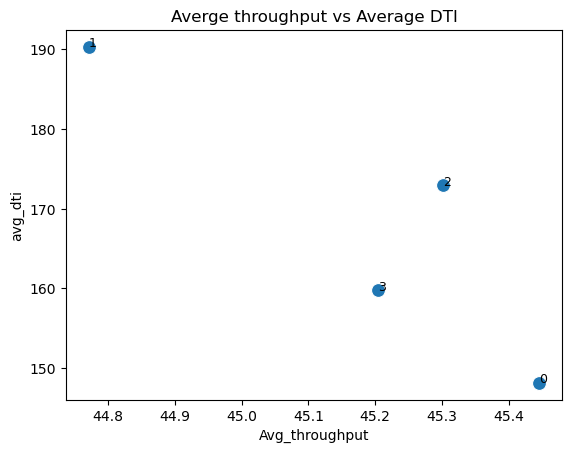

In [41]:
#visualize

sns.scatterplot(data=branch_analysis,x='Avg_throughput',y='avg_dti',s=100)
for i, row in branch_analysis.iterrows():
    plt.text(row['Avg_throughput'],row['avg_dti'],i,fontsize=9)
plt.title('Averge throughput vs Average DTI')
plt.show()

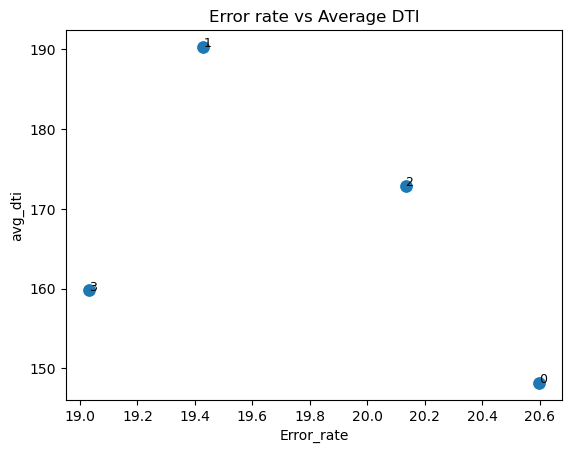

In [43]:
#visualize error rate vs avg dti

sns.scatterplot(data=branch_analysis,x='Error_rate',y='avg_dti',s=100)
for i, row in branch_analysis.iterrows():
    plt.text(row['Error_rate'],row['avg_dti'],i,fontsize=9)
plt.title('Error rate vs Average DTI')
plt.show()

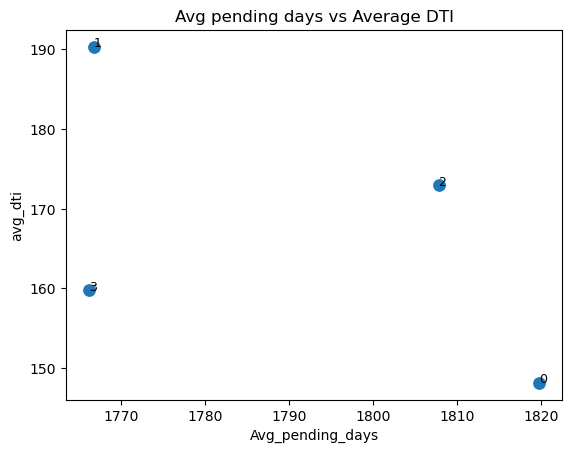

In [45]:
#visualize avg_pending days vs avg dti

sns.scatterplot(data=branch_analysis,x='Avg_pending_days',y='avg_dti',s=100)
for i, row in branch_analysis.iterrows():
    plt.text(row['Avg_pending_days'],row['avg_dti'],i,fontsize=9)
plt.title('Avg pending days vs Average DTI')
plt.show()

In [5]:
#elevated failure or default rate across branch

txn_d=pd.read_csv('Txn_metric.csv')
txn_d.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12239 entries, 0 to 12238
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Customer_ID         12239 non-null  object 
 1   Branch              12239 non-null  object 
 2   txn_count           12239 non-null  int64  
 3   Total_txn_amnt      12239 non-null  int64  
 4   Total_success_amnt  5460 non-null   float64
 5   Total_failed_amnt   2843 non-null   float64
 6   Total_pending_amnt  2861 non-null   float64
 7   Total_unknown_amnt  2981 non-null   float64
 8   Success_txn         12239 non-null  int64  
 9   Failed_txn          12239 non-null  int64  
 10  Pending_txn         12239 non-null  int64  
 11  Unk_txn             12239 non-null  int64  
 12  Success_rate        12239 non-null  float64
 13  Failed_rate         12239 non-null  float64
 14  Pending_rate        12239 non-null  float64
 15  Unknown_rate        12239 non-null  float64
dtypes: f

In [7]:
txn_d=txn_d.fillna(0)

In [9]:
txn_d.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12239 entries, 0 to 12238
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Customer_ID         12239 non-null  object 
 1   Branch              12239 non-null  object 
 2   txn_count           12239 non-null  int64  
 3   Total_txn_amnt      12239 non-null  int64  
 4   Total_success_amnt  12239 non-null  float64
 5   Total_failed_amnt   12239 non-null  float64
 6   Total_pending_amnt  12239 non-null  float64
 7   Total_unknown_amnt  12239 non-null  float64
 8   Success_txn         12239 non-null  int64  
 9   Failed_txn          12239 non-null  int64  
 10  Pending_txn         12239 non-null  int64  
 11  Unk_txn             12239 non-null  int64  
 12  Success_rate        12239 non-null  float64
 13  Failed_rate         12239 non-null  float64
 14  Pending_rate        12239 non-null  float64
 15  Unknown_rate        12239 non-null  float64
dtypes: f

In [11]:
#Failed rate
branch_f_rate = txn_d.groupby('Branch')['Failed_rate'].mean()
print(branch_f_rate)

Branch
CALICUT       0.204250
CHENNAI       0.193231
KOCHI         0.198088
TRIVANDRUM    0.193838
Name: Failed_rate, dtype: float64


In [13]:
#Success rate
branch_s_rate = txn_d.groupby('Branch')['Success_rate'].mean()
print(branch_s_rate)

Branch
CALICUT       0.390080
CHENNAI       0.405116
KOCHI         0.393195
TRIVANDRUM    0.394323
Name: Success_rate, dtype: float64


In [15]:
#pending rate
branch_p_rate = txn_d.groupby('Branch')['Pending_rate'].mean()
print(branch_p_rate)

Branch
CALICUT       0.195755
CHENNAI       0.192898
KOCHI         0.201713
TRIVANDRUM    0.209682
Name: Pending_rate, dtype: float64


In [17]:
#unknown rate
branch_u_rate = txn_d.groupby('Branch')['Unknown_rate'].mean()
print(branch_u_rate)

Branch
CALICUT       0.209914
CHENNAI       0.208754
KOCHI         0.207004
TRIVANDRUM    0.202157
Name: Unknown_rate, dtype: float64


In [21]:
#default rate
data3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 23 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Loan_ID          5000 non-null   object 
 1   Customer_ID      5000 non-null   object 
 2   Loan_Type        5000 non-null   object 
 3   Sanction_Amount  5000 non-null   int64  
 4   Interest_Rate    5000 non-null   float64
 5   Tenure_Months    5000 non-null   int64  
 6   EMI              5000 non-null   float64
 7   Loan_Status      5000 non-null   object 
 8   Branch           5000 non-null   object 
 9   Income           5000 non-null   int64  
 10  Credit_score     5000 non-null   int64  
 11  Monthly_Income   5000 non-null   float64
 12  DTI              5000 non-null   float64
 13  LTI              5000 non-null   float64
 14  Emi_burden       5000 non-null   float64
 15  Interest_burden  5000 non-null   float64
 16  Credit_risk      5000 non-null   object 
 17  default_flag  

In [35]:
def_rate=data3[data3['Loan_Status'] == 'default']
total_loan=data3.groupby('Branch')['Loan_uid'].count()
total_def_loan= def_rate.groupby('Branch')['Loan_uid'].count()
print(total_def_loan)
print(total_loan)
branch_loan=pd.DataFrame(total_loan).rename_columns('Branch','Total_loan').reset_index()
branch_def_rate.head()
#branch_

Branch
calicut       129
chennai       154
kochi         155
trivandrum    133
Name: Loan_uid, dtype: int64
Branch
calicut       1278
chennai       1219
kochi         1254
trivandrum    1249
Name: Loan_uid, dtype: int64


AttributeError: 'DataFrame' object has no attribute 'rename_columns'